# **Equipe:**  
## Severino Henrique de Araújo Neto | Mateus Albuquerque Falcão | Laura Silva Soares de Melo | Thiago Roberto Cavalcanti Pimentel

**Data:** Abril de 2026

# Estratégias de Treinamento - Exercício 04

## Importar bibliotecas
** Importe pandas, seaborn e as bibliotecas usuais. **

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

Metodos de Redução de Dimensionalidada que vão ser usados:

- Extração de Features 

- Redução de Features

#### PCA (Análise de Componentes Principais)

O PCA é uma técnica usada para reduzir a quantidade de variáveis de um conjunto de dados, criando novas variáveis chamadas componentes principais. Essas componentes são combinações das variáveis originais e são criadas para manter o máximo de informação possível.

Cada componente representa uma nova dimensão dos dados e é organizada pela quantidade de variância explicada. A primeira componente explica mais informação, a segunda explica a maior parte do que sobra, e assim por diante. Além disso, as componentes não são correlacionadas entre si.

Quanto mais componentes são utilizadas, mais parecido o novo conjunto de dados fica com o original, mas o objetivo do PCA é usar poucas componentes para manter a informação essencial e simplificar a análise.

# Usando o algoritmo PCA para diminuir a dimensionalidade



1.   Gere uma base de dados com make_classification (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html#sklearn.datasets.make_classification)
4.   Faça a separação em treino e teste
5.   Utilize o algoritmo PCA https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html?highlight=pca#sklearn.decomposition.PCA e gere mais dois conjuntos de dados com 10 e 5 features, além dos dados originais
6.   Treine modelos de k-NN com os dados originais e os dados gerados pelo PCA
6.   Analise os resultados


In [3]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, # O número de amostras.
    n_features=20, # O número de características.
    n_informative=3, # O número de características informativas.
    n_redundant=0, # O número de características redundantes.
    n_repeated=0, # O número de características repetidas.
    n_classes=2, # O número de classes.
    random_state=0, # O estado aleatório para garantir a reprodutibilidade.
    shuffle=False, # Se as amostras devem ser embaralhadas ou não.
)

# Divisão treino-teste

Use o método train_test_split para dividir seus dados em um conjunto treino e teste.

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# Separando os dados em treino e teste (75% treino e 25% teste) e removendo a coluna 'class' das features
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.25, random_state=111
)

In [6]:
print(f"Tamanho do conjunto de treino: {X_train.shape}")
print(f"Tamanho do conjunto de teste: {X_test.shape}")

Tamanho do conjunto de treino: (750, 20)
Tamanho do conjunto de teste: (250, 20)


In [7]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,2.923432,0.415867,-0.690162,-0.113122,-0.214289,0.029451,0.827101,-0.050277,-0.232539,0.968222,-0.440896,1.008792,-1.635817,-1.739650,-0.340555,1.364876,-1.521737,0.061454,-1.993390,1.966708
1,1.744308,1.535805,0.413509,0.397505,0.388923,0.519913,-0.573505,-1.388376,-0.591348,1.789067,0.588576,0.412257,1.579689,0.875418,0.245639,-0.892871,0.681396,0.465043,1.012710,1.374857
2,-2.072800,1.220255,-2.212028,1.443938,0.368642,0.739604,0.531963,2.143730,0.387917,1.666139,0.864043,-0.674494,0.601879,0.470448,0.732804,-0.136456,1.457040,-0.841638,-1.658650,1.248114
3,0.595470,1.618292,0.869758,-0.550781,1.359296,-1.985801,0.768060,0.181027,-1.322011,1.315267,-0.934209,1.745640,0.417005,-0.532068,0.422391,-0.490293,0.431905,0.648150,-0.556883,0.155376
4,-1.074168,0.089330,-1.826083,-1.198839,-1.460382,1.712329,-0.597427,-1.076623,0.255850,-0.420043,-1.184401,0.079405,1.094663,-0.814111,-1.451154,0.351138,-0.392302,-0.571994,0.455800,0.129281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,1.259228,0.093750,-0.170545,-0.145614,-0.305567,0.022338,0.033837,-1.033990,1.670193,-2.631995,-0.652061,-0.482154,-0.042979,-0.776220,2.106576,-0.489806,-0.448134,-0.737414,1.242988,-0.399053
746,-0.167795,-1.064876,0.548325,0.739557,1.040714,-0.821612,-0.690663,0.323779,0.196112,1.045185,0.573334,0.426461,0.164445,-0.550351,-0.788338,0.347695,0.557746,-1.679785,-0.758403,0.297600
747,1.102762,1.617529,-0.137752,-1.836307,1.447674,-0.261039,-0.631118,0.814594,-0.400019,0.197014,-1.418650,1.246415,-0.612698,0.062948,-0.794200,-1.133524,0.515778,-0.076092,0.226114,0.516449
748,0.460563,0.304735,1.743974,-0.164564,-1.225236,-1.031973,-1.476970,-0.771503,-1.015393,1.572609,-1.094883,0.622019,0.214341,0.145393,0.699119,-0.303463,-0.375053,0.381186,-2.088375,0.004993


## Utilizando o algoritmo PCA

In [8]:
from sklearn.decomposition import PCA

Com 10 features

In [9]:
# PCA com 10 componentes
pca_10 = PCA(n_components=10, random_state=42) # Criando o objeto PCA com 10 componentes e um estado aleatório para reprodutibilidade
pca_10.fit(X_train)

,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [10]:
X_train_pca10 = pca_10.transform(X_train)
X_test_pca10 = pca_10.transform(X_test)

print(f"Variância explicada (10 componentes): {pca_10.explained_variance_ratio_.sum():.4f}")
print(f"Shape após PCA: {X_train_pca10.shape}")

Variância explicada (10 componentes): 0.6070
Shape após PCA: (750, 10)


Com 5 features

In [11]:
# PCA com 5 componentes
pca_5 = PCA(n_components=5, random_state=42)
pca_5.fit(X_train)

,n_components,5
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [12]:
X_train_pca5 = pca_5.transform(X_train)
X_test_pca5 = pca_5.transform(X_test)

print(f"Variância explicada (5 componentes): {pca_5.explained_variance_ratio_.sum():.4f}")
print(f"Shape após PCA: {X_train_pca5.shape}")

Variância explicada (5 componentes): 0.3618
Shape após PCA: (750, 5)


## Treinando os modelos com todas as features, com 10 e 5 features do PCA

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

Todas as features

In [14]:
# k-NN com todas as features
knn_all = KNeighborsClassifier(n_neighbors=5)
knn_all.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [15]:
# Avaliação do modelo com todas as features
y_pred_all = knn_all.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)

10 features geradas pelo PCA

In [16]:
# k-NN com 10 features do PCA
knn_pca10 = KNeighborsClassifier(n_neighbors=5)
knn_pca10.fit(X_train_pca10, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
y_pred_pca_10 = knn_pca10.predict(X_test_pca10)
acc_pca10 = accuracy_score(y_test, y_pred_pca_10)

5 features geradas pelo PCA

In [18]:
# k-NN com 5 features do PCA
knn_pca5 = KNeighborsClassifier(n_neighbors=5)
knn_pca5.fit(X_train_pca5, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
y_pred_pca5 = knn_pca5.predict(X_test_pca5)
acc_pca5 = accuracy_score(y_test, y_pred_pca5)

In [20]:
print("=== MODELO COM TODAS AS FEATURES (20) ===") # Imprime o título para indicar que os resultados a seguir são do modelo com todas as features
print(f"Acurácia: {acc_all:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_all))

=== MODELO COM TODAS AS FEATURES (20) ===
Acurácia: 0.7840

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       127
           1       0.76      0.83      0.79       123

    accuracy                           0.78       250
   macro avg       0.79      0.78      0.78       250
weighted avg       0.79      0.78      0.78       250



10 features geradas pelo PCA

In [21]:
print("=== MODELO COM 10 FEATURES DO PCA ===")
print(f"Acurácia: {acc_pca10:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca_10))

=== MODELO COM 10 FEATURES DO PCA ===
Acurácia: 0.7640

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       127
           1       0.75      0.78      0.76       123

    accuracy                           0.76       250
   macro avg       0.76      0.76      0.76       250
weighted avg       0.76      0.76      0.76       250



5 features geradas pelo PCA

In [22]:
print("=== MODELO COM 5 FEATURES DO PCA ===")
print(f"Acurácia: {acc_pca5:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca5))

=== MODELO COM 5 FEATURES DO PCA ===
Acurácia: 0.7920

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       127
           1       0.77      0.83      0.80       123

    accuracy                           0.79       250
   macro avg       0.79      0.79      0.79       250
weighted avg       0.79      0.79      0.79       250



-------------------------

## Obtenha os dados
** Leia o arquivo csv 'Arvore_Decisao_Iris_Data.csv' em um DataFrame **

In [23]:
path = "C:/Users/melos/OneDrive - Claro SA/LAURA SILVA SOARES DE MELO/eng._e_ analise_de_dados/bases/Arvore_Decisao_Iris_Data.csv"
df = pd.read_csv(path, header=None)

In [24]:
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

In [25]:
df.columns = columns

Convertendo o target em labels numérica

In [26]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [27]:
le = LabelEncoder()

In [28]:
df['class_numero'] = le.fit_transform(df['class'])

In [29]:
print("Mapeamento de classes:")
for i, classe in enumerate(le.classes_):
    print(f"{classe} -> {i}")

Mapeamento de classes:
Iris-setosa -> 0
Iris-versicolor -> 1
Iris-virginica -> 2


In [30]:
print("\nDataframe com classe numérica:")
print(df.head())


Dataframe com classe numérica:
   sepal_length  sepal_width  petal_length  petal_width        class  \
0           5.1          3.5           1.4          0.2  Iris-setosa   
1           4.9          3.0           1.4          0.2  Iris-setosa   
2           4.7          3.2           1.3          0.2  Iris-setosa   
3           4.6          3.1           1.5          0.2  Iris-setosa   
4           5.0          3.6           1.4          0.2  Iris-setosa   

   class_numero  
0             0  
1             0  
2             0  
3             0  
4             0  


In [31]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,class_numero
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,1.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Divisão treino-teste

Use o método train_test_split para dividir seus dados em um conjunto treino e teste.

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
# Separando features e target
X_iris = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y_iris = df['class_numero'].values

# Dividindo em treino e teste
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.25, random_state=111
)

print(f"Tamanho treino: {X_train_iris.shape}")
print(f"Tamanho teste: {X_test_iris.shape}")

Tamanho treino: (112, 4)
Tamanho teste: (38, 4)


# Normalização as variáveis

Hora de para padronizar as variáveis.

Import StandardScaler do Scikit-learn.

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
scaler = StandardScaler()

Converta as variáveis independentes com o StandardScaler

In [36]:
scaler.fit(X_train_iris)

,copy,True
,with_mean,True
,with_std,True


Use o método .transform () para transformar os parâmetros em uma versão padronizada.

In [37]:
X_train_scaled = scaler.transform(X_train_iris)
X_test_scaled = scaler.transform(X_test_iris)

print("Dados normalizados!")
print(f"Média do treino normalizado: {X_train_scaled.mean(axis=0)}")
print(f"Desvio padrão do treino normalizado: {X_train_scaled.std(axis=0)}")

Dados normalizados!
Média do treino normalizado: [ 4.03447117e-16  6.59938374e-16 -7.98964070e-16  9.71445147e-17]
Desvio padrão do treino normalizado: [1. 1. 1. 1.]


# Usando o algoritmo Random Forest como Feature Selection

Importe o RandomForestClassfier e SelectFromModel do scikit learn.

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

from sklearn.metrics import accuracy_score

In [39]:
clf = RandomForestClassifier()

In [40]:
clf.fit(X_train_scaled, y_train_iris)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
# Fazendo predições
y_pred_rf = clf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test_iris, y_pred_rf)

Analisando a accuracy:

In [42]:
print(f"Acurácia Random Forest: {acc_rf:.4f}")

Acurácia Random Forest: 0.9211


Ranking de importância das features:
1. petal_width: 0.4652
2. petal_length: 0.4322
3. sepal_length: 0.0844
4. sepal_width: 0.0182


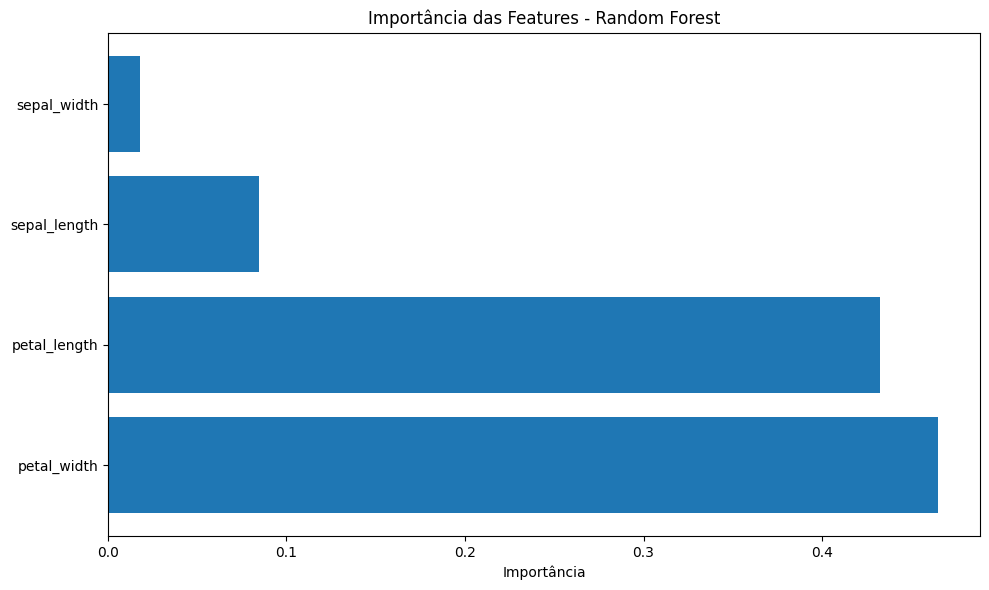

In [43]:
# Visualizando importância das features
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1] # Ordena as importâncias em ordem decrescente

print("Ranking de importância das features:")
for f in range(len(feature_names)):
    print(f"{f + 1}. {feature_names[indices[f]]}: {importances[indices[f]]:.4f}")

# Plotando
plt.figure(figsize=(10, 6))
plt.title("Importância das Features - Random Forest")
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

Referência: https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

## Utilizando e analisando feature selection do modelo Random Forest via SelectFromModel (sklearn)

In [44]:
# Usando SelectFromModel
sfm = SelectFromModel(clf, prefit=True)

In [45]:
# Verificando quais features foram selecionadas pelo modelo
selected_features = sfm.get_support()
print("Features selecionadas:")
for i, selected in enumerate(selected_features): 
    if selected:
        print(f"  - {feature_names[i]}")

print(f"\nNúmero de features selecionadas: {selected_features.sum()}")


Features selecionadas:
  - petal_length
  - petal_width

Número de features selecionadas: 2


In [46]:
# Transformando os dados com apenas as features selecionadas
X_train_selected = sfm.transform(X_train_scaled)
X_test_selected = sfm.transform(X_test_scaled)

print(f"Shape após seleção: {X_train_selected.shape}")

Shape após seleção: (112, 2)


---------------------------------------------------------------------------------------

## Validação Cruzada com k-NN

### Aplique a validação cruzada para as bases de dados utilizadas neste exercício

Utilize o conjunto de dados com todas as features gerados a partir do sklearn. Primeira parte dos exercícios com PCA.

In [47]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay

#### Dados **gerados com a função da base de dados gerada pelo sklearn (PCA)**

k=5

In [48]:
# Treinando KNN com validação cruzada nos dados originais
knn = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')

print(f"Scores de validação cruzada: {cv_scores}")
print(f"Média: {cv_scores.mean():.4f}")
print(f"Desvio padrão: {cv_scores.std():.4f}")

Scores de validação cruzada: [0.82       0.79333333 0.8        0.72       0.76      ]
Média: 0.7787
Desvio padrão: 0.0351


In [49]:
# Treinando e gerando matriz de confusão
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)


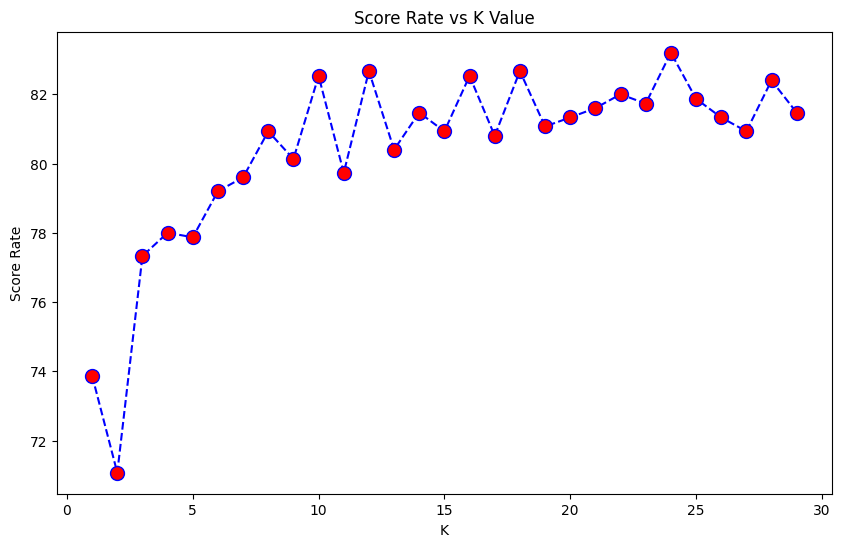

In [50]:
from sklearn.model_selection import cross_val_score

score = []

for i in range(1,30):
  # Modelo com K = i
  knn_cv = KNeighborsClassifier(n_neighbors=i)
  # Cross validation com 5 folds
  cv_scores = cross_val_score(knn_cv, X_train, y_train, cv=5, scoring='accuracy')
  # Adiciona média dos scores convertida para porcentagem
  score.append(round((cv_scores.mean()*100), 2))

plt.figure(figsize=(10,6))
plt.plot(range(1,30), score, color='blue', linestyle='dashed', marker='o',
           markerfacecolor = 'red', markersize=10)
plt.title('Score Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Score Rate')
plt.show()

Classification Report do modelo treinado com o melhor valor de k

Melhor valor de K: 24
Melhor score: 83.2%
=== MODELO KNN COM K=24 ===

Acurácia: 0.8360

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       127
           1       0.81      0.87      0.84       123

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250



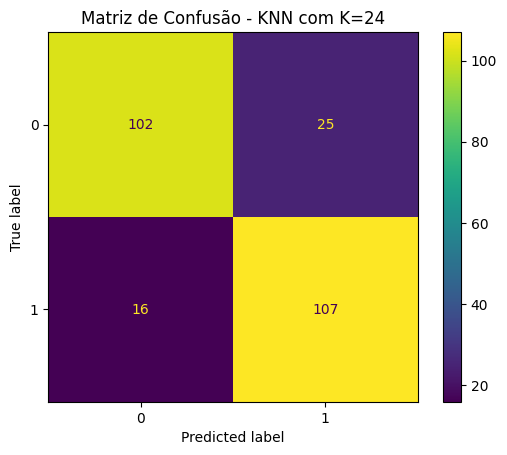

In [51]:
# Encontrando o melhor K
best_k = score.index(max(score)) + 1
print(f"Melhor valor de K: {best_k}")
print(f"Melhor score: {max(score)}%")

# Treinando com o melhor K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

print(f"=== MODELO KNN COM K={best_k} ===")
print(f"\nAcurácia: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f'Matriz de Confusão - KNN com K={best_k}')
plt.show()

#### Dados **Iris**

Ponto extra

In [52]:
# Treinando KNN com validação cruzada nos dados Iris
knn_iris = KNeighborsClassifier(n_neighbors=5)
cv_scores_iris = cross_val_score(knn_iris, X_train_scaled, y_train_iris, cv=5, scoring='accuracy')

print(f"Scores de validação cruzada (Iris): {cv_scores_iris}")
print(f"Média: {cv_scores_iris.mean():.4f}")
print(f"Desvio padrão: {cv_scores_iris.std():.4f}")

Scores de validação cruzada (Iris): [0.86956522 0.95652174 0.95454545 1.         1.        ]
Média: 0.9561
Desvio padrão: 0.0476


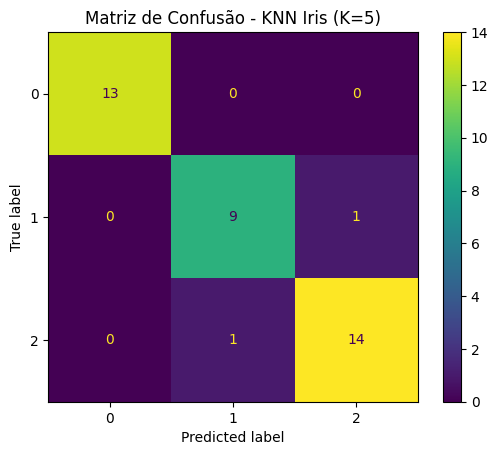

In [53]:
# Treinando e gerando matriz de confusão para Iris
knn_iris.fit(X_train_scaled, y_train_iris)
y_pred_iris = knn_iris.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(y_test_iris, y_pred_iris)
plt.title('Matriz de Confusão - KNN Iris (K=5)')
plt.show()

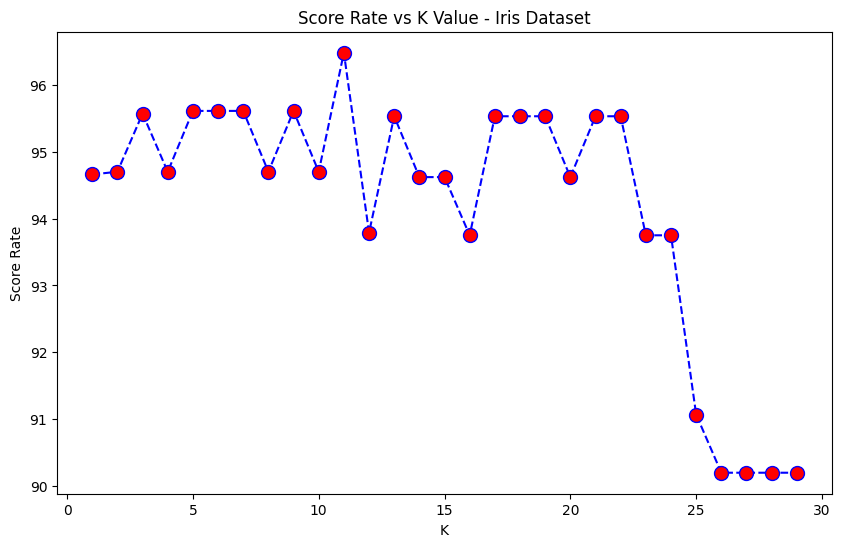

In [54]:
from sklearn.model_selection import cross_val_score

score = []

for i in range(1,30):
  # Modelo com K = i
  knn_cv = KNeighborsClassifier(n_neighbors=i)
  # Cross validation com 5 folds nos dados Iris normalizados
  cv_scores = cross_val_score(knn_cv, X_train_scaled, y_train_iris, cv=5, scoring='accuracy')
  # Adiciona média dos scores convertida para porcentagem
  score.append(round((cv_scores.mean()*100), 2))

plt.figure(figsize=(10,6))
plt.plot(range(1,30), score, color='blue', linestyle='dashed', marker='o',
           markerfacecolor = 'red', markersize=10)
plt.title('Score Rate vs K Value - Iris Dataset')
plt.xlabel('K')
plt.ylabel('Score Rate')
plt.show()

Classification Report do modelo treinado com o melhor valor de k

Melhor valor de K: 11
Melhor score: 96.48%
=== MODELO KNN IRIS COM K=11 ===

Acurácia: 0.9737

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.91      1.00      0.95        10
           2       1.00      0.93      0.97        15

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



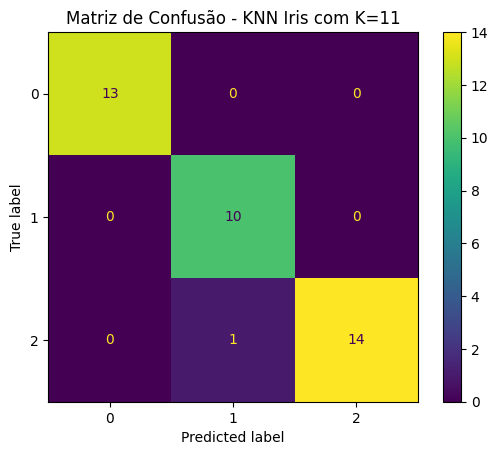

In [55]:
# Encontrando o melhor K para Iris
best_k_iris = score.index(max(score)) + 1
print(f"Melhor valor de K: {best_k_iris}")
print(f"Melhor score: {max(score)}%")

# Treinando com o melhor K
knn_best_iris = KNeighborsClassifier(n_neighbors=best_k_iris)
knn_best_iris.fit(X_train_scaled, y_train_iris)
y_pred_best_iris = knn_best_iris.predict(X_test_scaled)

print(f"=== MODELO KNN IRIS COM K={best_k_iris} ===")
print(f"\nAcurácia: {accuracy_score(y_test_iris, y_pred_best_iris):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_iris, y_pred_best_iris))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test_iris, y_pred_best_iris)
plt.title(f'Matriz de Confusão - KNN Iris com K={best_k_iris}')
plt.show()

## Conclusão

Descreva o que você identificou como melhoria ou não da utilização das abordagens do PCA, feature selection e Cross Validation.

PARTE 1: ANÁLISE DETALHADA DO PCA 

    1.1 Conceitos fundamentais (o que é, como funciona matematicamente)
    1.2 Resultados experimentais com tabela comparativa
    1.3 Benefícios detalhados (4 categorias: custo, multicolinearidade, ruído, visualização)
    1.4 Limitações e cuidados (interpretabilidade, linearidade, escala, escolha de componentes)

PARTE 2: FEATURE SELECTION COM RANDOM FOREST

    2.1 Conceitos fundamentais (3 tipos de feature selection)
    2.2 Como Random Forest calcula importância (mecanismo interno + fórmula)
    2.3 Resultados no dataset Iris (interpretação biológica!)
    2.4 Vantagens detalhadas (interpretabilidade, insights, redução de custos, overfitting)
    2.5 PCA vs Feature Selection (tabela comparativa completa)

PARTE 3: VALIDAÇÃO CRUZADA

    3.1 O problema da divisão treino-teste simples (demonstração numérica)
    3.2 Como funciona K-Fold CV (algoritmo passo-a-passo + visual)
    3.3 Análise do gráfico K vs Score (trade-off viés-variância explicado)
    3.4 Vantagens da validação cruzada (4 benefícios detalhados)
    3.5 Variações de CV (5 tipos: K-Fold, Stratified, LOO, Time Series, Nested)

PARTE 4: COMPARAÇÃO GERAL E RECOMENDAÇÕES

    4.1 Lições fundamentais (5 lições com exemplos concretos)
    4.2 Guia de decisão prático (5 cenários com recomendações)
    4.3 Aplicações no mundo real (medicina, finanças, marketing, indústria, agricultura)
    4.4 Considerações avançadas (pipeline completo, data leakage, curse of dimensionality)
    4.5 Melhores práticas (lista do que SEMPRE fazer e NUNCA fazer)
    4.6 Próximos passos de aprendizado (técnicas avançadas para estudar)

